# Used Car Price Prediction using Multiple Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("used_cars.csv")

data.head(3)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"


##Data Cleaning



In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [ ]:
#basic statistics
data.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [ ]:
#check data types
data.dtypes

,0
brand,object
model,object
model_year,int64
milage,object
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


In [ ]:
#clean price remove '$' and commas
data['price'] = data['price'].str.replace(',', '').str.replace('$', '').astype(float)

#clean milage remove 'mi' and commas
data['milage'] = data['milage'].str.replace(',', '').str.replace(' mi.', '').astype(float)

In [ ]:
print("Milage\n", data['milage'].head())
print("Price\n", data['price'].head())

Milage
 0    51000.0
1    34742.0
2    22372.0
3    88900.0
4     9835.0
Name: milage, dtype: float64
Price
 0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
Name: price, dtype: float64


In [ ]:
#clean engine in liters
data['engine_size'] = data['engine'].str.extract(r'(\d+\.\d+)L').astype(float)

In [ ]:
data[['price', 'milage', 'engine_size', 'model_year']].describe()

,price,milage,engine_size,model_year
count,4.009000e+03,4009.000000,3613.000000,4009.000000
mean,4.455319e+04,64717.551010,3.710836,2015.515590
std,7.871064e+04,52296.599459,1.424105,6.104816
min,2.000000e+03,100.000000,0.650000,1974.000000
25%,1.720000e+04,23044.000000,2.500000,2012.000000
50%,3.100000e+04,52775.000000,3.500000,2017.000000
75%,4.999000e+04,94100.000000,4.700000,2020.000000
max,2.954083e+06,405000.000000,8.400000,2024.000000


In [ ]:
data.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [ ]:
#cleanning
data['engine_size'] = data['engine_size'].fillna(0)
data['fuel_type'] = data['fuel_type'].fillna('unknown')
data['accident'] = data['accident'].fillna('unknown')
data['clean_title'] = data['clean_title'].fillna('unknown')

In [ ]:
#for accident 1 = yes, 0 = none
data['accident_check'] = data['accident'].str.contains('accident', case=False, na=False).astype(int)

In [ ]:
#clean title 1 = yes, 0 = no
data['clean_title_check'] = (data['clean_title'].fillna('no').str.strip().str.lower() == "yes").astype(int)

In [ ]:
#making car age
data['car_age'] = 2026 - data['model_year']

print(data[['model_year','car_age']].head(5))

   model_year  car_age
0        2013       13
1        2021        5
2        2022        4
3        2015       11
4        2021        5


In [ ]:
print(data.isnull().sum())

brand                0
model                0
model_year           0
milage               0
fuel_type            0
engine               0
transmission         0
ext_col              0
int_col              0
accident             0
clean_title          0
price                0
engine_size          0
accident_check       0
clean_title_check    0
car_age              0
dtype: int64


In [ ]:
#save the clean csv

data.to_csv("car_cleaned.csv", index = False)
print('saved')

saved


## Feature Engineering

In [ ]:
print('Brand', data['brand'].nunique())
print('Fuel type', data['fuel_type'].nunique())

Brand 57
Fuel type 8


In [ ]:
#too many unique value in brands. so just take top 10 most used brands
top_brands = data['brand'].value_counts().nlargest(10).index
data['brand'] = data['brand'].apply(lambda x: x if x in top_brands else 'others')
data['brand'].value_counts()

,count
brand,
others,1605
Ford,386
BMW,375
Mercedes-Benz,315
Chevrolet,292
Porsche,201
Audi,200
Toyota,199
Lexus,163


In [ ]:
data['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,3309
Hybrid,194
unknown,170
E85 Flex Fuel,139
Diesel,116
–,45
Plug-In Hybrid,34
not supported,2


In [ ]:
#replace the fuel type unwanted values
unwanted = ["not supported", "–", "unknown"]
data['fuel_type'] = data['fuel_type'].apply(lambda x: "others" if x in unwanted else x)
data['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,3309
others,217
Hybrid,194
E85 Flex Fuel,139
Diesel,116
Plug-In Hybrid,34


In [ ]:
#encode brands and fuel

data = pd.get_dummies(data, columns = ["fuel_type", "brand"], drop_first = True)

print(data.shape)
print(data.columns.tolist())

(4009, 29)
['model', 'model_year', 'milage', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price', 'engine_size', 'accident_check', 'clean_title_check', 'car_age', 'fuel_type_E85 Flex Fuel', 'fuel_type_Gasoline', 'fuel_type_Hybrid', 'fuel_type_Plug-In Hybrid', 'fuel_type_others', 'brand_BMW', 'brand_Chevrolet', 'brand_Ford', 'brand_Jeep', 'brand_Land', 'brand_Lexus', 'brand_Mercedes-Benz', 'brand_Porsche', 'brand_Toyota', 'brand_others']


In [ ]:
data.head(3)

,model,model_year,milage,engine,transmission,ext_col,int_col,accident,clean_title,price,...,brand_BMW,brand_Chevrolet,brand_Ford,brand_Jeep,brand_Land,brand_Lexus,brand_Mercedes-Benz,brand_Porsche,brand_Toyota,brand_others
0,Utility Police Interceptor Base,2013,51000.0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,...,False,False,True,False,False,False,False,False,False,False
1,Palisade SEL,2021,34742.0,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,...,False,False,False,False,False,False,False,False,False,True
2,RX 350 RX 350,2022,22372.0,3.5 Liter DOHC,Automatic,Blue,Black,None reported,unknown,54598.0,...,False,False,False,False,False,True,False,False,False,False


##EDA and Correlation Analysis


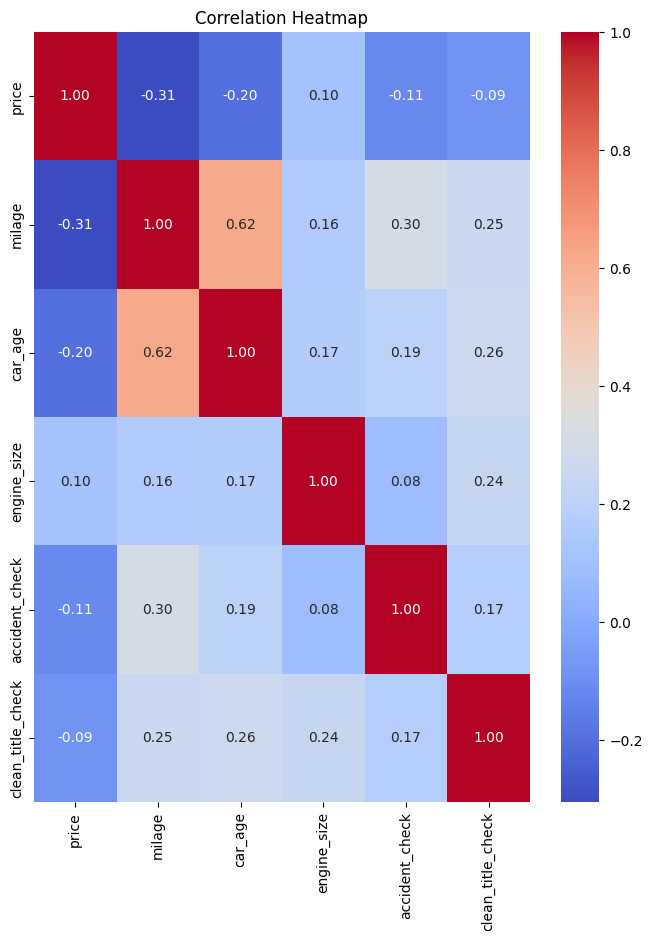

In [34]:
#correlation
cols = ['price','milage','car_age','engine_size','accident_check', 'clean_title_check']

plt.figure(figsize=(8,10))
sns.heatmap(data[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

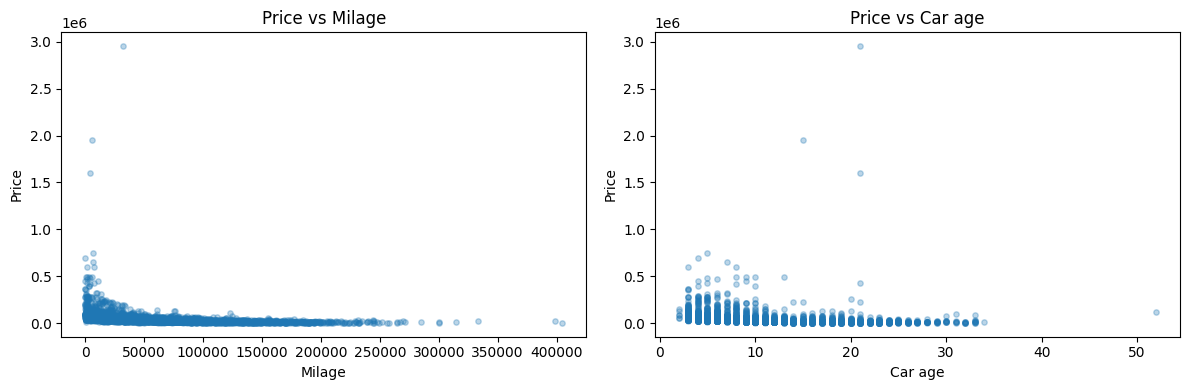

In [42]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].scatter(data["milage"], data["price"], alpha=0.3, s=15)
axes[0].set_title("Price vs Milage")
axes[0].set_xlabel("Milage")
axes[0].set_ylabel("Price")

axes[1].scatter(data["car_age"], data["price"], alpha=0.3, s=15)
axes[1].set_title("Price vs Car age")
axes[1].set_xlabel("Car age")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

In [43]:
#clear outliers

lower = data['price'].quantile(0.01)
high = data['price'].quantile(0.99)

data = data[(data['price'] >= lower) & (data['price']<=high)]

print(data.shape)
print(data["price"].describe())

(3932, 29)
count      3932.000000
mean      39882.209308
std       34818.663129
min        4000.000000
25%       17500.000000
50%       31000.000000
75%       49445.250000
max      269991.000000
Name: price, dtype: float64


##Model Building

In [44]:
#split the data

features = ['milage','engine_size', 'accident_check', 'clean_title_check', 'car_age', 'fuel_type_E85 Flex Fuel', 'fuel_type_Gasoline', 'fuel_type_Hybrid', 'fuel_type_Plug-In Hybrid', 'fuel_type_others', 'brand_BMW', 'brand_Chevrolet', 'brand_Ford', 'brand_Jeep', 'brand_Land', 'brand_Lexus', 'brand_Mercedes-Benz', 'brand_Porsche', 'brand_Toyota', 'brand_others']

X = data[features]
y = data['price']

print(X.shape, y.shape)

(3932, 20) (3932,)


In [46]:
#train ,test, and split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

print("Train: ", X_train.shape)
print("Test: ", X_test.shape)

Train:  (3145, 20)
Test:  (787, 20)


In [47]:
#model training

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained")

Model Trained


##Model Evaluation



In [54]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2 : {r2:.4f}")
print(f"MAE : {mae:,.0f} $")
print(f"RMSE : {rmse:,.0f} $")

R^2 : 0.4203
MAE : 16,167 $
RMSE : 27,574 $


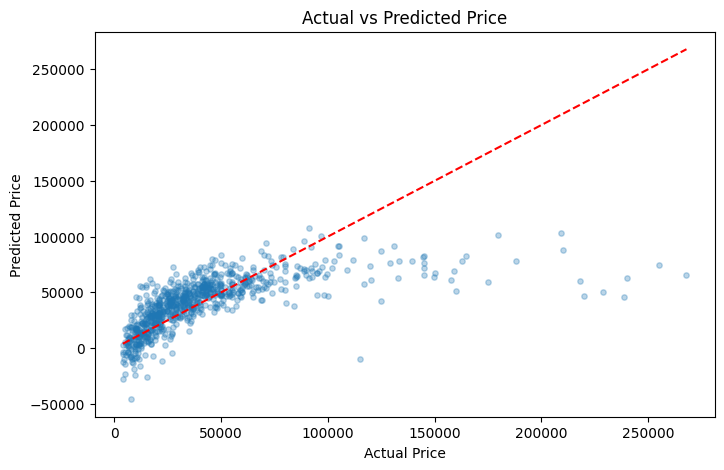

In [56]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.3, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Actual vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

##Predicting New Car Prices

In [60]:
new_car = pd.DataFrame([{
    "brand" : "Toyota",
    "model_year" : 2019,
    "milage" : 45000,
    "engine_size" : 2.5
}])

new_car_encoded = pd.get_dummies(new_car)

In [66]:
new_car_encoded = new_car_encoded.reindex(columns=X.columns, fill_value = 0)

prediction = model.predict(new_car_encoded)
print(prediction)

[65747.67223934]


##Conclusion

This project successfully built a Multiple Linear Regression (MLR) model to predict used car prices based on key features such as mileage, car age, engine size, accident history, clean title status, fuel type, and brand.